In [2]:
import ROOT
import os
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import uproot
import awkward as ak

/usr/local/lib/python3.10/dist-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.10); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [3]:
file = "/scratch/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A/MasterAnaDev_mc_AnaTuple_run00110000_Playlist.root"
with uproot.open(file) as uf:
    master_ana_dev = uf["MasterAnaDev"]


In [ ]:
from dataclasses import dataclass
@dataclass
class DenseCollection:
    bounds: np.ndarray  # shape (n_events + 1,)
    data: np.ndarray    # shape (n_total_particles, n_features)
    n: np.ndarray       # shape (n_events,) - simply the one-difference of bounds
    keys: list = None
    column_widths: list = None


def get_dense(keys, master_ana_dev_frame):
    column_arrays = [master_ana_dev_frame[key].array() for key in keys]
    # Get number of particles per event from mc_part_arrays[0]
    n_per_event = ak.num(column_arrays[0])
    column_arrays = [ak.flatten(arr).to_numpy() for arr in column_arrays]
    column_widths = []
    for i in column_arrays:
        if len(i.shape) == 1:
            column_widths.append(1)
        else:
            column_widths.append(i.shape[1])
    # Now, put the mc_part_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    matrix = np.zeros((len(column_arrays[0]), sum(column_widths)), dtype = np.float32)
    # Replace the nans with zeros
    start_idx = 0
    for i, arr in enumerate(column_arrays):
        if column_widths[i] == 1:
            matrix[:, start_idx] = arr
        else:
            matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    event_boundaries = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    event_boundaries[1:] = np.cumsum(n_per_event)
    return DenseCollection(bounds=event_boundaries, data=matrix, n=n_per_event.to_numpy(), keys=keys, column_widths=column_widths)



In [26]:
def get_muons(master_ana_dev_frame, only_keep_minos_matched=True):
    # Slightly special treatment for muons
    muon_keys = ["muon_corrected_p", "muon_theta", "muon_phi", "muon_thetaX", "muon_thetaY", "muon_fuzz_energy", "muon_iso_blobs_energy", "MasterAnaDev_muon_E", "MasterAnaDev_muon_Px", "MasterAnaDev_muon_Py", "MasterAnaDev_muon_Pz"]
    # filter out cases where muon_corrected_p[:, 0] == -999 and muon_corrected_p[:, 1]] == -999
    muon_arrays = [master_ana_dev_frame[key].array() for key in muon_keys]
    if only_keep_minos_matched:
        mask = (muon_arrays[0][:, 0] != -999) & (muon_arrays[0][:, 1] != -999)
    else:
        #mask = master_ana_dev_frame["truth_reco_has_muon"].array()
        mask = np.ones(len(muon_arrays[0]), dtype=bool)
        mask = ak.from_numpy(mask)
    muon_arrays = [arr[mask].to_numpy() for arr in muon_arrays]
    # Exclude muons with abs of any component of any key > 1e6 - some weird anomalies
    n_muon_per_event = mask.to_numpy().astype(np.int32)
    # now put the muon_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    muon_matrix = np.zeros((len(muon_arrays[0]), len(muon_keys)+3), dtype=np.float32)
    column_widths = [4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    start_idx = 0
    for i, arr in enumerate(muon_arrays):
        if column_widths[i] == 1:
            muon_matrix[:, start_idx] = arr
        else:
            muon_matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    muon_event_boundaries = np.zeros(len(n_muon_per_event) + 1, dtype=np.int32)
    muon_event_boundaries[1:] = np.cumsum(n_muon_per_event)
    # Use: mc_part_event_boundaries and mc_part_matrix
    return DenseCollection(bounds=muon_event_boundaries, data=muon_matrix, n=n_muon_per_event, keys=muon_keys, column_widths=column_widths)

def remove_overflows(coll: DenseCollection):
    # Some entries in the data matrix are weird.
    data_anomalies = np.where(np.abs(coll.data).max(axis=1) > 1e6)[0]
    data_anomalies_set = set(list(data_anomalies))
    n_per_event = coll.n.copy()
    data_filtered = np.delete(coll.data, data_anomalies, axis=0)
    event_bounds_old = coll.bounds
    # go through event bounds and create a new event bounds without the removed particles.
    #  shape of n_per_event should stay the same, just some events will have less (or 0) particles after removing.
    event_bounds_new = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    n_per_event_new = np.zeros(len(n_per_event), dtype=np.int32)
    
    for event_idx in range(len(n_per_event)):
        # Get the particle indices for this event
        start_particle_idx = event_bounds_old[event_idx]
        end_particle_idx = event_bounds_old[event_idx + 1]
        
        # Count how many particles in this event are NOT anomalies
        n_removed = 0
        for particle_idx in range(start_particle_idx, end_particle_idx):
            if particle_idx in data_anomalies_set:
                n_removed += 1
        
        # Update the new particle count for this event
        n_per_event_new[event_idx] = n_per_event[event_idx] - n_removed
        # Update the event bounds
        event_bounds_new[event_idx + 1] = event_bounds_new[event_idx] + n_per_event_new[event_idx]
    
    return DenseCollection(bounds=event_bounds_new, data=data_filtered, n=n_per_event_new, keys=coll.keys, column_widths=coll.column_widths)


In [27]:
mc_part_keys = ["mc_FSPartPx", "mc_FSPartPy", "mc_FSPartPz", "mc_FSPartE", "mc_FSPartPDG"]
prong_keys = ["prong_part_pos", "prong_part_E", "prong_part_score", "prong_part_mass", "prong_part_charge", "prong_part_pid"]
blob_keys = ["MasterAnaDev_BlobX", "MasterAnaDev_BlobY", "MasterAnaDev_BlobZ", "MasterAnaDev_BlobT", "MasterAnaDev_BlobTPos", "MasterAnaDev_BlobTotalE"]

# This cell creates a compact gather of the observables easy to analyze both per event and all together over the whole dataset
mc_part = get_dense(mc_part_keys, master_ana_dev)
prong = get_dense(prong_keys, master_ana_dev)
blob = get_dense(blob_keys, master_ana_dev)

In [28]:
muon = get_muons(master_ana_dev, only_keep_minos_matched=True)
muon_all = get_muons(master_ana_dev, only_keep_minos_matched=False)
muon = remove_overflows(muon)
muon_all = remove_overflows(muon_all)

In [29]:
muon_all.n.mean(), muon.n.mean()

(0.9997908162991649, 0.7050241633992888)

Column prong_part_pos_0 contains NaN values: [ -451.49384  -424.70987 -1036.75    ...     0.        437.85376
     0.     ]
N of nan vals:  2
Column prong_part_pos_1 contains NaN values: [-760.25134 -770.4511   530.76044 ...    0.       858.4868     0.     ]
N of nan vals:  2
Column prong_part_E_0 contains NaN values: [1129.1034   251.28247  177.17438 ...    0.      -523.01483    0.     ]
N of nan vals:  1
Column prong_part_E_1 contains NaN values: [ -19.460188 -310.50043  -681.25854  ...    0.       -896.1821
    0.      ]
N of nan vals:  1
Column prong_part_E_2 contains NaN values: [11270.744     448.75677  4299.9062  ...     0.       6445.185
     0.     ]
N of nan vals:  1


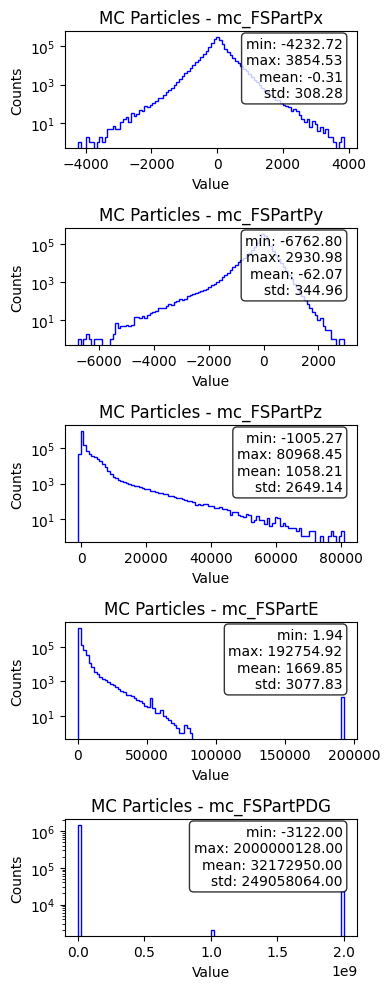

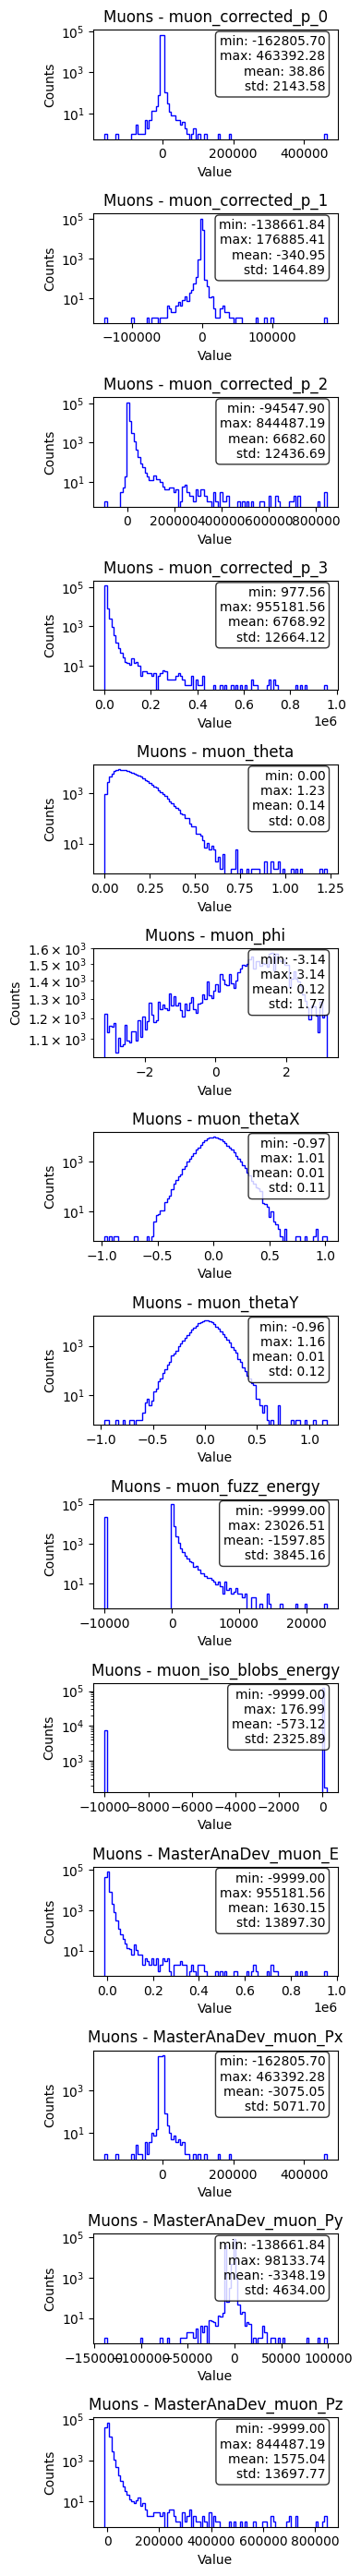

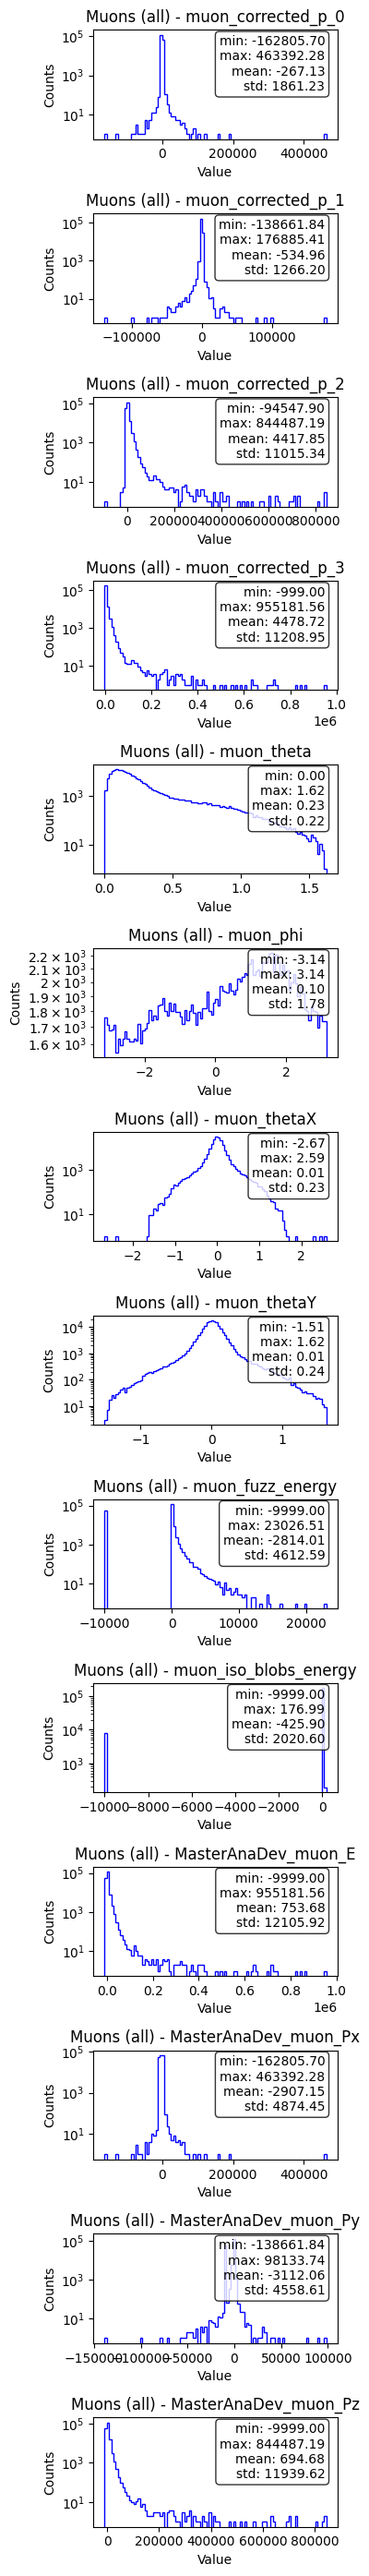

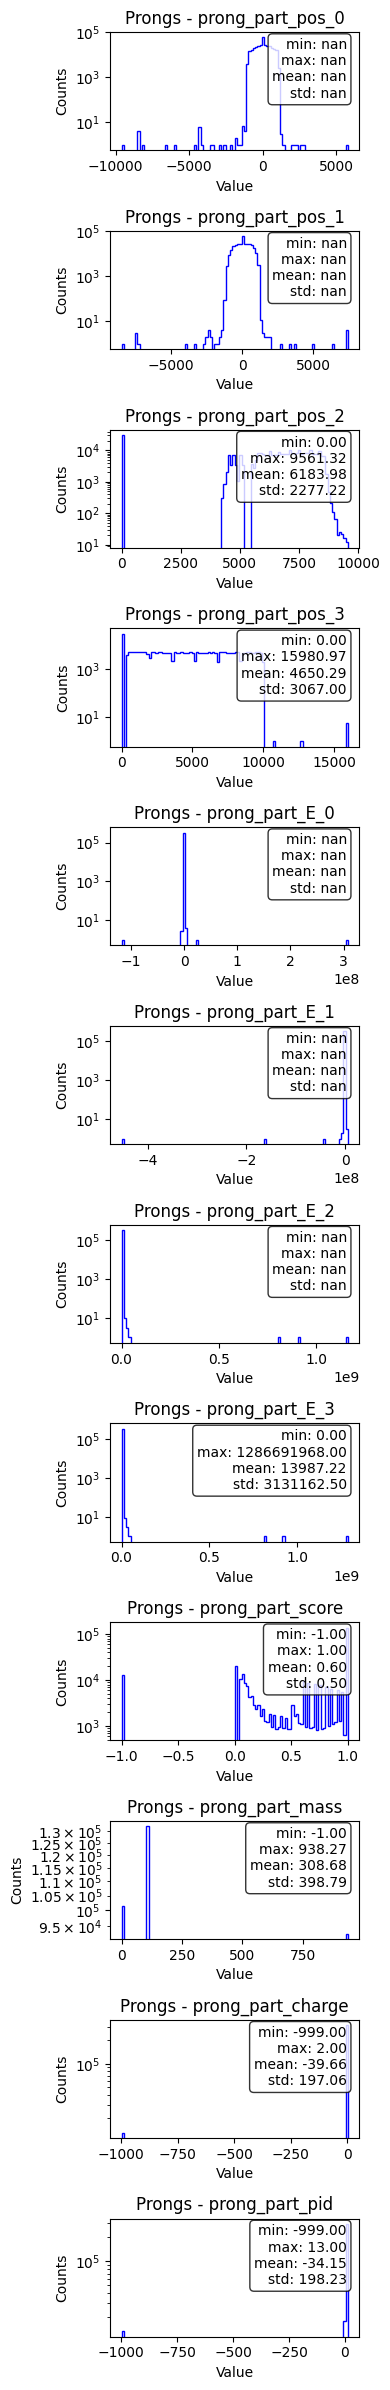

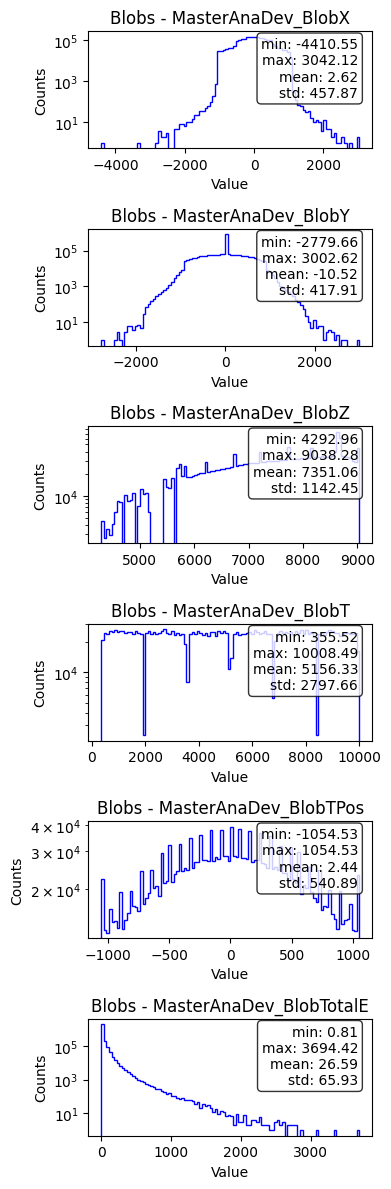

In [30]:
# Muon, MC_part, prong, and blob, make compact histograms of all the column values (all in one figure but separate plots stacked on top of each other).
# If column width > 1, make just a plot of the first component.
# Include some summary statistics (min, max, mean, std), and print them on the plots too. Make a separate figure for each of the four collections.

def plot_collection(collection: DenseCollection, collection_name: str, output_file: str = None):
    n_columns = len(collection.data[0])
    column_names = []
    for i in range(len(collection.keys)):
        if collection.column_widths[i] == 1:
            column_names.append(collection.keys[i])
        else:
            for j in range(collection.column_widths[i]):
                column_names.append(f"{collection.keys[i]}_{j}")
    fig, axes = plt.subplots(n_columns, 1, figsize=(4, 2 * n_columns))
    if n_columns == 1:
        axes = [axes]
    for i in range(n_columns):
        data_column = collection.data[:,i]
        # get column name + component (if applicable)
        column_name = column_names[i]
        axes[i].hist(data_column, bins=100, histtype='step', color='blue')
        axes[i].set_title(f"{collection_name} - {column_name}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Counts")
        axes[i].set_yscale("log")
        # compute summary statistics
        col_min = np.min(data_column)
        if np.isnan(col_min):
            # print the data column if its nan
            print(f"Column {column_name} contains NaN values:", data_column)
            print("N of nan vals: ", np.isnan(data_column).sum())
        col_max = np.max(data_column)
        col_mean = np.mean(data_column)
        col_std = np.std(data_column)
        stats_text = f"min: {col_min:.2f}\nmax: {col_max:.2f}\nmean: {col_mean:.2f}\nstd: {col_std:.2f}"
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    fig.tight_layout()
    if output_file:
        fig.savefig(output_file)
    else:
        fig.show()

plot_collection(mc_part, "MC Particles", "out/mc_part_stats.pdf")
plot_collection(muon, "Muons", "out/muon_stats.pdf")
plot_collection(muon_all, "Muons (all)", "out/muon_all_stats.pdf")
plot_collection(prong, "Prongs", "out/prong_stats.pdf")
plot_collection(blob, "Blobs", "out/blob_stats.pdf")


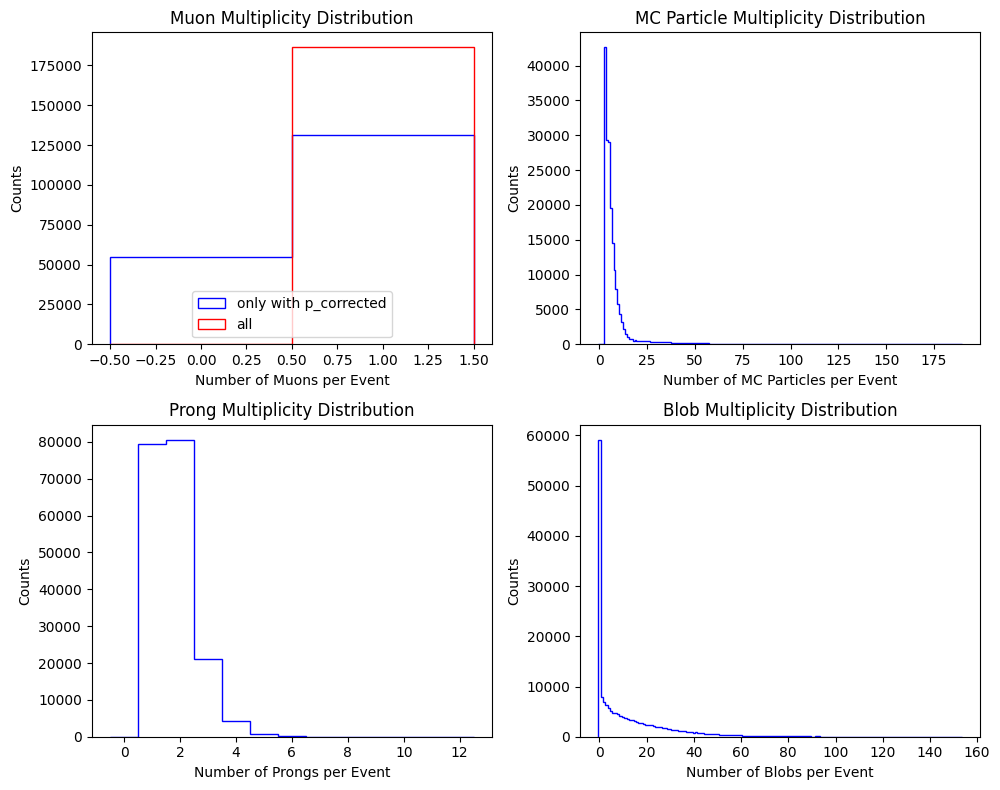

In [31]:
# Plot histograms - distributions of N muons, M MC particles, N prongs, and N blobs per event.
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
bins_muon = [0, 1, 2]
ax[0, 0].hist(muon.n, bins=bins_muon, histtype='step', color='blue', align='left', rwidth=0.5, label="only with p_corrected")
ax[0, 0].hist(muon_all.n, bins=bins_muon, histtype='step', color='red', align='left', rwidth=0.5, label="all")
ax[0, 0].set_xlabel("Number of Muons per Event")
ax[0, 0].set_ylabel("Counts")
ax[0, 0].set_title("Muon Multiplicity Distribution")
ax[0, 0].legend()
bins_mc_part = np.arange(0, np.max(mc_part.n) + 2) - 0.5
ax[0, 1].hist(mc_part.n, bins=bins_mc_part, histtype='step', color='blue')
ax[0, 1].set_xlabel("Number of MC Particles per Event")
ax[0, 1].set_ylabel("Counts")
ax[0, 1].set_title("MC Particle Multiplicity Distribution")
bins_prong = np.arange(0, np.max(prong.n) + 2) - 0.5
ax[1, 0].hist(prong.n, bins=bins_prong, histtype='step', color='blue')
ax[1, 0].set_xlabel("Number of Prongs per Event")
ax[1, 0].set_ylabel("Counts")
ax[1, 0].set_title("Prong Multiplicity Distribution")
bins_blob = np.arange(0, np.max(blob.n) + 2) - 0.5
ax[1, 1].hist(blob.n, bins=bins_blob, histtype='step', color='blue')
ax[1, 1].set_xlabel("Number of Blobs per Event")
ax[1, 1].set_ylabel("Counts")
ax[1, 1].set_title("Blob Multiplicity Distribution")
fig.tight_layout()
fig.savefig("out/multiplicity_distributions.pdf")
fig.show()


In [32]:
# print statistics for the multiplicities of MC particles, prongs, blobs, muons (min, max, mean)
print(f"MC Particles: Min multiplicity: {np.min(mc_part.n)}, Max multiplicity: {np.max(mc_part.n)}, Mean multiplicity: {np.mean(mc_part.n)}")
print(f"Prongs: Min multiplicity: {np.min(prong.n)}, Max multiplicity: {np.max(prong.n)}, Mean multiplicity: {np.mean(prong.n)}")
print(f"Blobs: Min multiplicity: {np.min(blob.n)}, Max multiplicity: {np.max(blob.n)}, Mean multiplicity: {np.mean(blob.n)}")
print(f"Muons: Min multiplicity: {np.min(muon.n)}, Max multiplicity: {np.max(muon.n)}, Mean multiplicity: {np.mean(muon.n)}")
print(f"Muons (all): Min multiplicity: {np.min(muon_all.n)}, Max multiplicity: {np.max(muon_all.n)}, Mean multiplicity: {np.mean(muon_all.n)}")

MC Particles: Min multiplicity: 2, Max multiplicity: 189, Mean multiplicity: 8.23340073697027
Prongs: Min multiplicity: 1, Max multiplicity: 12, Mean multiplicity: 1.7487811026662876
Blobs: Min multiplicity: 0, Max multiplicity: 153, Mean multiplicity: 12.451482790617844
Muons: Min multiplicity: 0, Max multiplicity: 1, Mean multiplicity: 0.7050241633992888
Muons (all): Min multiplicity: 0, Max multiplicity: 1, Mean multiplicity: 0.9997908162991649


In [33]:
# print % with zero multiplicity for each of the collections
print("Percentage of events with zero multiplicity:")
print(f"MC Particles: {np.sum(mc_part.n == 0) / len(mc_part.n)}")
print(f"Prongs: {np.sum(prong.n == 0) / len(prong.n)}")
print(f"Blobs: {np.sum(blob.n == 0) / len(blob.n)}")
print(f"Muons: {np.sum(muon.n == 0) / len(muon.n)}")
print(f"Muons (all): {np.sum(muon_all.n == 0) / len(muon_all.n)}")



Percentage of events with zero multiplicity:
MC Particles: 0.0
Prongs: 0.0
Blobs: 0.3172619462666073
Muons: 0.29497583660071125
Muons (all): 0.0002091837008351257


In [ ]:
E_nu_MC = master_ana_dev["mc_incomingE"].array().to_numpy()
MC_current = master_ana_dev["mc_current"].array().to_numpy() # 1=CC, 2=NC

# From the CCQE formula purely from the reconstructed muon:
E_nu_from_formula = np.zeros(len(muon.n))
Emu = muon.data[:, 3]
E_muon_per_event = np.zeros(len(muon.n))
pmu = np.linalg.norm(muon.data[:, 0:3], axis=1)
mu_theta_cos = muon.data[:, 2] / np.linalg.norm(muon.data[:, 0:3], axis=1)
proton_mass = 938.2720813505859
muon_mass = 105.6583745
E_nu_formula = (2 * proton_mass * Emu - muon_mass * muon_mass) / (2 * (proton_mass - Emu + pmu * mu_theta_cos))

mu_idx = 0
for i in range(len(muon.n)):
    if muon.n[i] > 0:
        E_nu_from_formula[i] = E_nu_formula[mu_idx]
        E_muon_per_event[i] = Emu[mu_idx]
        mu_idx += 1
    else:
        E_nu_from_formula[i] = -1
        E_muon_per_event[i] = -1


# From the dataframe:
E_nu_from_df = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy()
E_nu_from_p_correction = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy()
E_nu_from_p_correction[E_nu_from_p_correction < 0] = 0
invalid_idx = np.where(E_nu_from_df < 0)[0]
E_nu_from_df[invalid_idx] = -1
E_nu_from_df_with_p_correction = E_nu_from_df + E_nu_from_p_correction
E_nu_from_df_with_p_correction[invalid_idx] = -1


In [73]:
def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    #fig_eff, ax_eff = plt.subplots(figsize=(5, 5)) # eff. vs mc_E plots
    #mc_E_bins_efficiency = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20] # for efficiency
    bins_E = np.linspace(0, 20, 200)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E / 1000, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E / 1000, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method] / 1000, bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method] / 1000, bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
    ax[0, 0].legend()
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend()
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend()
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend()
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    # put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)
    fig.tight_layout()
    return fig


In [77]:
results = {"CCQE formula": E_nu_from_formula, "Enu_from_muon": E_nu_from_df, "Enu_from_muon+p": E_nu_from_df_with_p_correction}

In [80]:
E_recoil = master_ana_dev['MasterAnaDev_hadron_recoil'].array().to_numpy()
E_recoil = np.where(E_recoil >= 0, E_recoil, -1)
E_recoil_CCinc = master_ana_dev['MasterAnaDev_hadron_recoil_CCInc'].array().to_numpy()
E_recoil_CCinc = np.where(E_recoil_CCinc >= 0, E_recoil_CCinc, -1)

invalid_muon = E_muon_per_event == -1
invalid_E_recoil = E_recoil == -1
invalid_E_recoil_CCinc = E_recoil_CCinc == -1

results["E_mu+E_recoil"] = E_muon_per_event + E_recoil
results["E_mu+E_recoil_CCinc"] = E_muon_per_event + E_recoil_CCinc

results["E_mu+E_recoil"][invalid_muon | invalid_E_recoil] = -1
results["E_mu+E_recoil_CCinc"][invalid_muon | invalid_E_recoil_CCinc] = -1


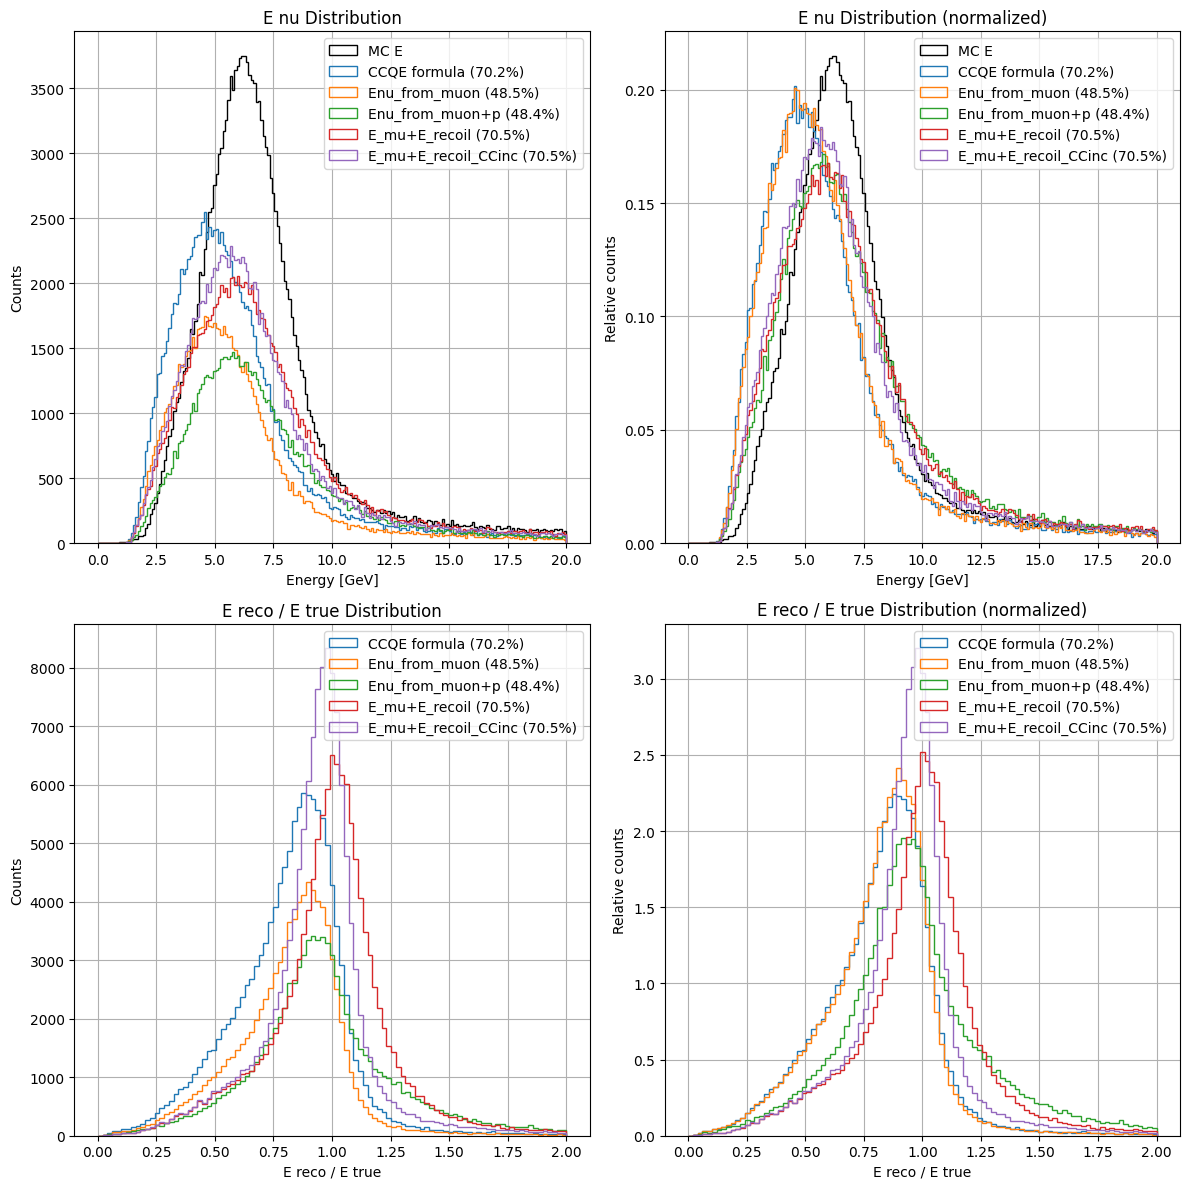

In [81]:
get_Enu_fig(E_nu_MC, results).show()

In [ ]:
# events without clean MINOS matched muons (?)
filter_no_minos_match = master_ana_dev["muon_corrected_p"].array().to_numpy()[:, 0] == -999


In [ ]:
# from muon_px
muon_E = muon_all.data[:, -4]
# Set muon p such that the mass will be right
muon_p = np.sqrt(muon_E**2)
muon_theta = muon_all.data[:, 4]
# use the CCQE formula to get E_muon from p and theta
E_muon_from_minerva = (2 * proton_mass * muon_E - muon_mass * muon_mass) / (2 * (proton_mass - muon_E + muon_p * muon_theta))
filter = muon_E > 0
E_muon_from_minerva = np.where(filter, E_muon_from_minerva, -1)

# ??? How to reconstruct E_nu from E_muon_from_minerva?


912371800000.0

In [94]:
muon_all.data[:, 3]

array([11344.86  ,  4358.4243,  4963.1997, ...,  -999.    ,  -999.    ,
        6529.032 ], dtype=float32)

array([-1169.039  ,  -734.6155 , -1334.106  , ...,   510.29025,
        -362.4835 ,  -728.2978 ], dtype=float32)

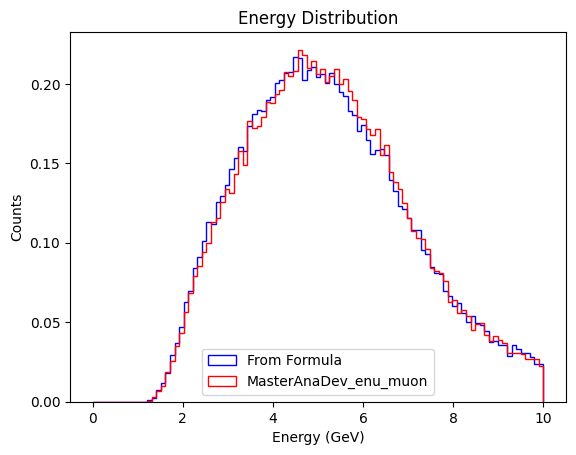

In [ ]:
# normalized E_nu_formula and from MasterAnaDev_enu_muon
fig, ax = plt.subplots()
bins = np.linspace(0, 10, 100)
ax.hist(E_nu_formula, bins=bins, histtype='step', color='blue', label='From Formula', density=True)
ax.hist(counts, bins=bins, histtype='step', color='red', label='MasterAnaDev_enu_muon', density=True)
ax.set_xlabel("Energy (GeV)")
ax.set_ylabel("Counts")
ax.legend()
ax.set_title("Energy Distribution")
fig.show()

In [ ]:
# check how many events have e from muon > 0 and e from proton > 0 and all intersections (basically a 2x2 conf mat)
muon_mask = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() > 0
proton_mask = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() > 0
confusion_matrix = np.zeros((2, 2))
for i in range(len(muon_mask)):
    if muon_mask[i] == 1:
        if proton_mask[i] == 1:
            confusion_matrix[0, 0] += 1
        else:
            confusion_matrix[0, 1] += 1
    else:
        if proton_mask[i] == 1:
            confusion_matrix[1, 0] += 1
        else:
            confusion_matrix[1, 1] += 1

In [ ]:
confusion_matrix

array([[40740., 49605.],
       [  193., 95901.]])

/tmp/ipykernel_1361/309436863.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


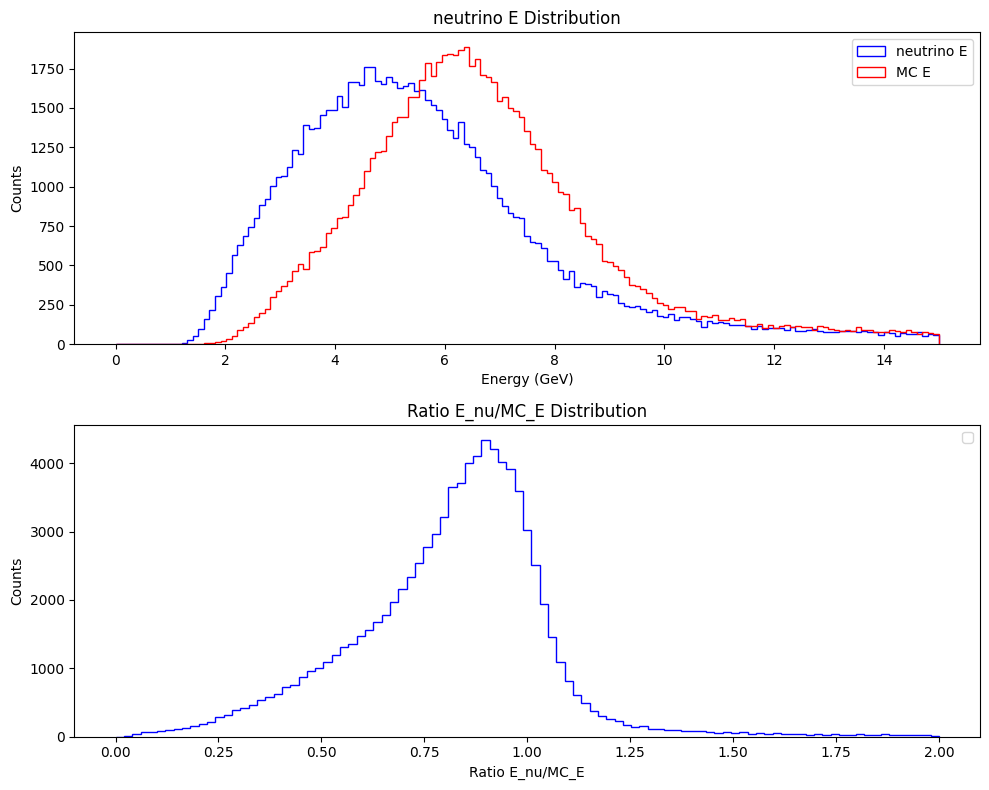

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = np.where(E_from_muon > 0, E_from_muon, E_from_proton)
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
ratio_use_muon_only = E_nu/MC_E
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1634/1791207600.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


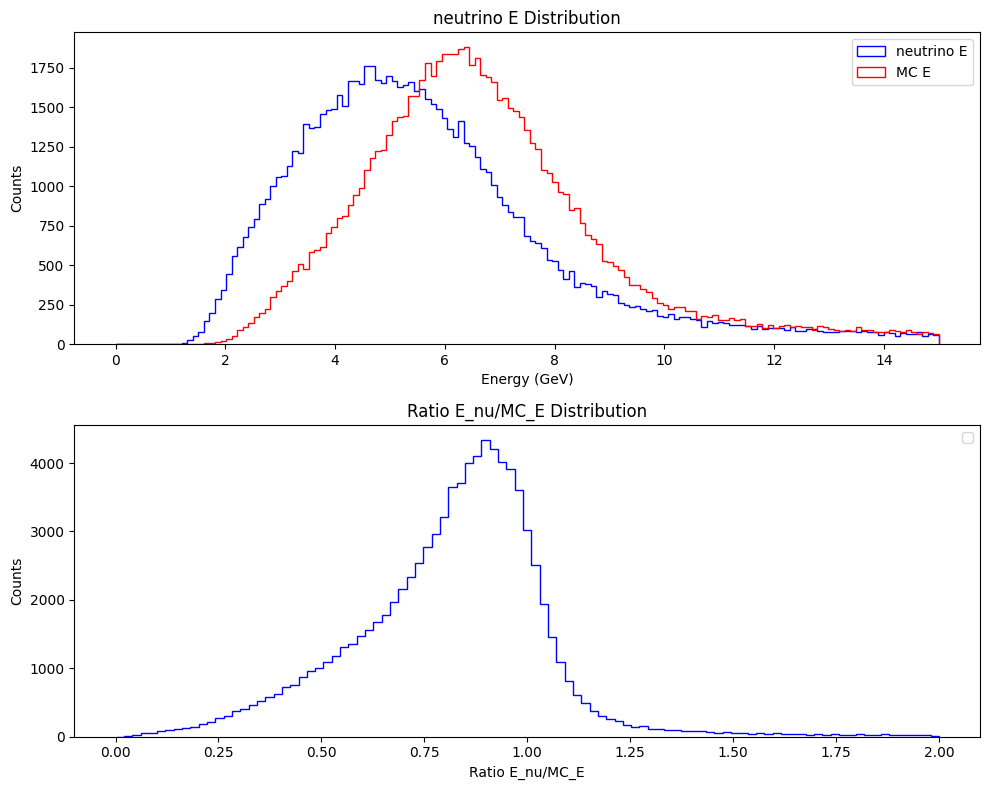

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_muon
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1634/2371775737.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


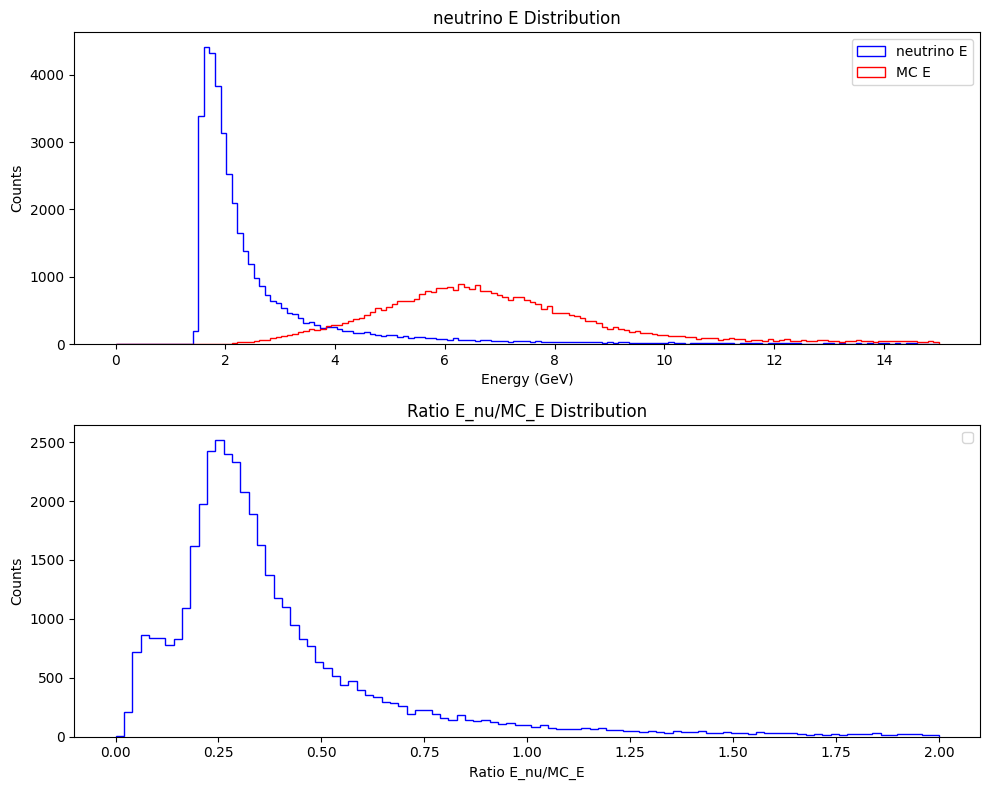

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_proton
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1361/3728430595.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


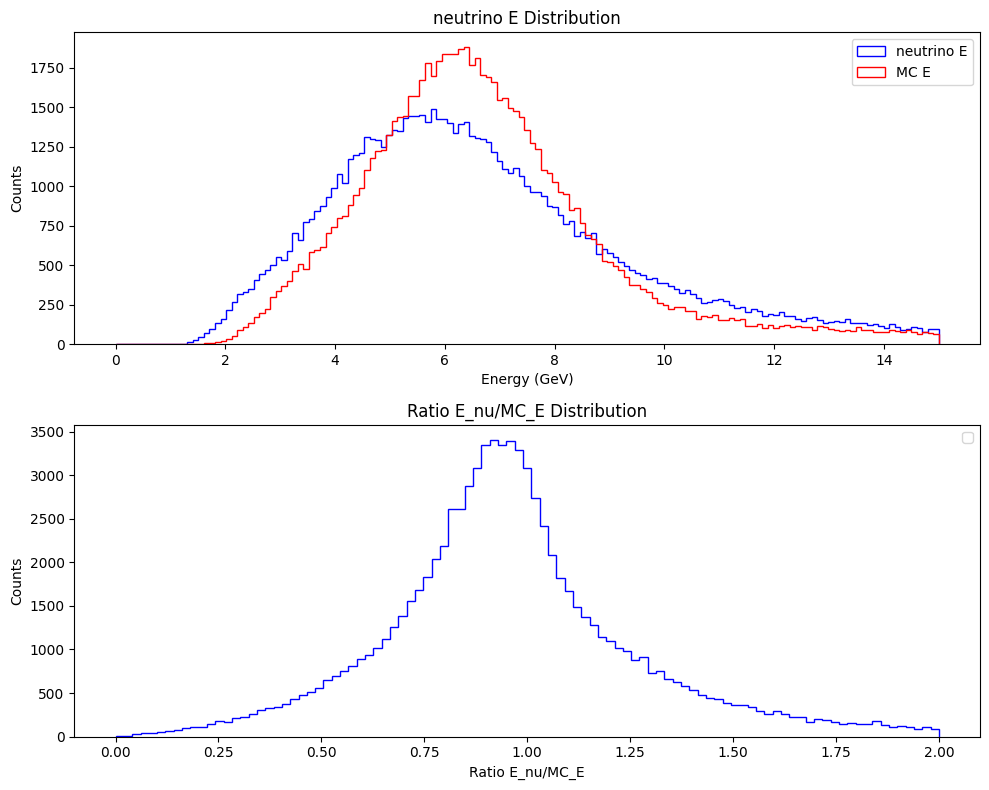

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_muon + np.where(E_from_proton > 0, E_from_proton, 0)
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
ratio_use_muon_and_proton = E_nu/MC_E
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

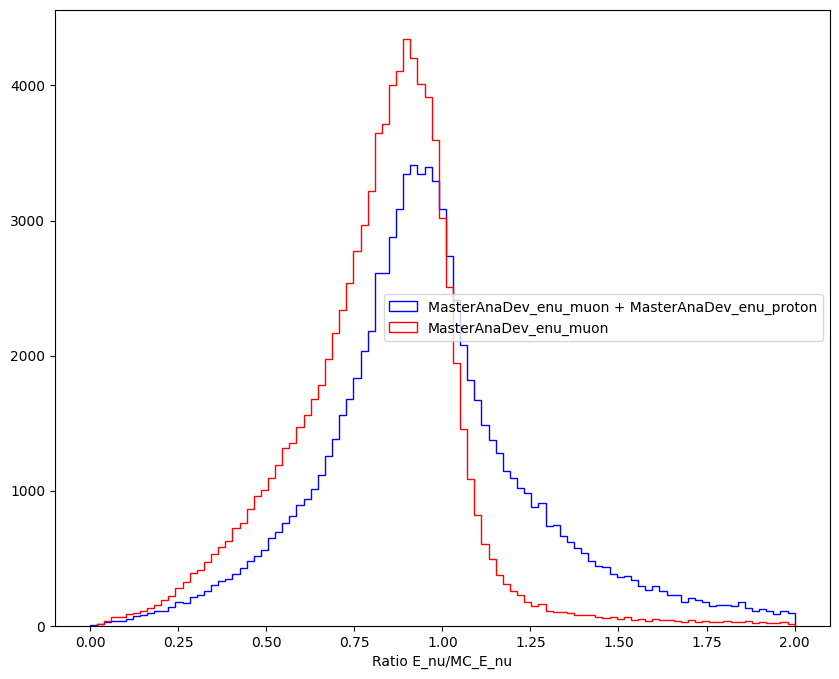

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.hist(ratio_use_muon_and_proton, bins=bins_ratio, histtype='step', color='blue', label='MasterAnaDev_enu_muon + MasterAnaDev_enu_proton')
ax.hist(ratio_use_muon_only, bins=bins_ratio, histtype='step', color='red', label='MasterAnaDev_enu_muon')
ax.legend()
ax.set_xlabel("Ratio E_nu/MC_E_nu")
fig.show()

In [ ]:
np.unique(mc_part.data[:, -1].astype(int))

array([     -3122,      -2212,      -2112,       -321,       -311,
             -211,        -16,        -14,        -13,        -12,
              -11,         11,         12,         13,         14,
               16,         22,        111,        130,        211,
              311,        321,       2112,       2212,       3112,
             3122,       3212,       3222, 1000060096, 1000070144,
       1000080128, 1000130240, 1000220480, 1000260544, 1000822080,
       2000000128])

In [ ]:
mc_part.bounds

array([      0,      11,      28, ..., 1535016, 1535024, 1535027],
      dtype=int32)

In [ ]:
mc_part.data[0:11, -1]

array([ -13., 2112., 2212., -211.,  111., 2212., 2212., 2212., 2112.,
       -211., 2112.], dtype=float32)

In [ ]:
master_ana_dev["mc_incomingE"].array().to_numpy()


array([16958.06921095,  5057.47995483,  5319.70144219, ...,
        3963.06455604,  8009.65274946,  7043.04398091])

In [ ]:
# Get the energy of the muon from mc_part as a sanity check (E of all particles - masses of particles)
mc_part.keys
evt_idx = -4


data = mc_part.data[mc_part.bounds[evt_idx]:mc_part.bounds[evt_idx+1]]
mass = np.sqrt(data[:, 3]**2 - data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2)
np.sum(data[:, 3] - mass)

/tmp/ipykernel_1634/4124960621.py:7: RuntimeWarning: invalid value encountered in sqrt
  mass = np.sqrt(data[:, 3]**2 - data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2)


nan

In [ ]:
data[:, 3]**2- data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2

array([-5.0000000e-01,  8.8035025e+05,  1.9479791e+04,  1.8219562e+04],
      dtype=float32)

In [ ]:
# compute the neutrino energy from mc particles
n_events = mc_part.n.shape[0]
E_nu = np.zeros(n_events)
for i in range(n_events):
    data = mc_part.data[mc_part.bounds[i]:mc_part.bounds[i+1]]
    E_particles = data[:, 3]
    p_size_particles = np.linalg.norm(data[:, 0:3], axis=1)
    mass = np.sqrt(E_particles**2 - p_size_particles**2)
    # replace nan with 0
    mass[np.isnan(mass)] = 0
    E_nu[i] = np.sum(E_particles - mass)




/tmp/ipykernel_1361/1267430897.py:8: RuntimeWarning: invalid value encountered in sqrt
  mass = np.sqrt(E_particles**2 - p_size_particles**2)


In [ ]:
E_nu_true = master_ana_dev["mc_incomingE"].array().to_numpy()
ratio_ideal_reconstruction = E_nu  / E_nu_true

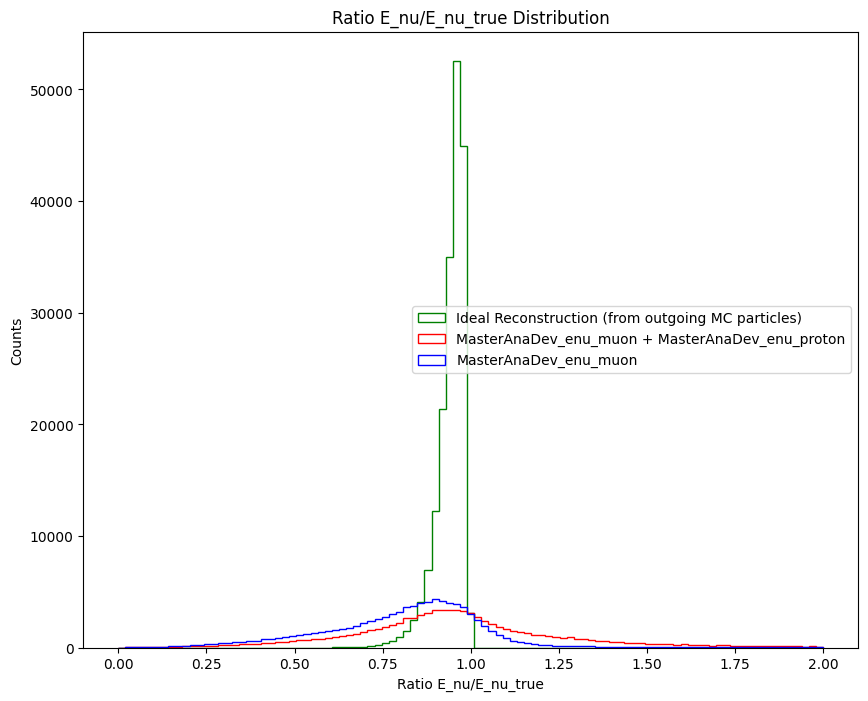

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
bins = np.linspace(0, 2, 100)
ax.hist(ratio_ideal_reconstruction, bins=bins, histtype='step', color='green', label='Ideal Reconstruction (from outgoing MC particles)')
ax.hist(ratio_use_muon_and_proton, bins=bins, histtype='step', color='red', label='MasterAnaDev_enu_muon + MasterAnaDev_enu_proton')
ax.hist(ratio_use_muon_only, bins=bins, histtype='step', color='blue', label='MasterAnaDev_enu_muon')
ax.set_xlabel("Ratio E_nu/E_nu_true")
ax.set_ylabel("Counts")
ax.set_title("Ratio E_nu/E_nu_true Distribution")
ax.legend()
fig.show()


In [ ]:
E_recoil = master_ana_dev['MasterAnaDev_hadron_recoil'].array().to_numpy()
E_recoil = np.where(E_recoil >= 0, E_recoil, 0)
E_recoil_CCinc = master_ana_dev['MasterAnaDev_hadron_recoil_CCInc'].array().to_numpy()
E_recoil_CCinc = np.where(E_recoil_CCinc >= 0, E_recoil_CCinc, 0)

array([11327.66922103, -9999.        ,  4963.19969681, ...,
         400.7244185 , -9999.        , -9999.        ])

In [ ]:
E_mu = master_ana_dev["muon_corrected_p"].array().to_numpy()[:, 3]
E_mu = np.where(E_mu >= 0, E_mu, 0)
E_nu_muon_recoil = (E_mu + E_recoil) / 1000

In [ ]:
np.where(E_mu==0)[0][3]

16

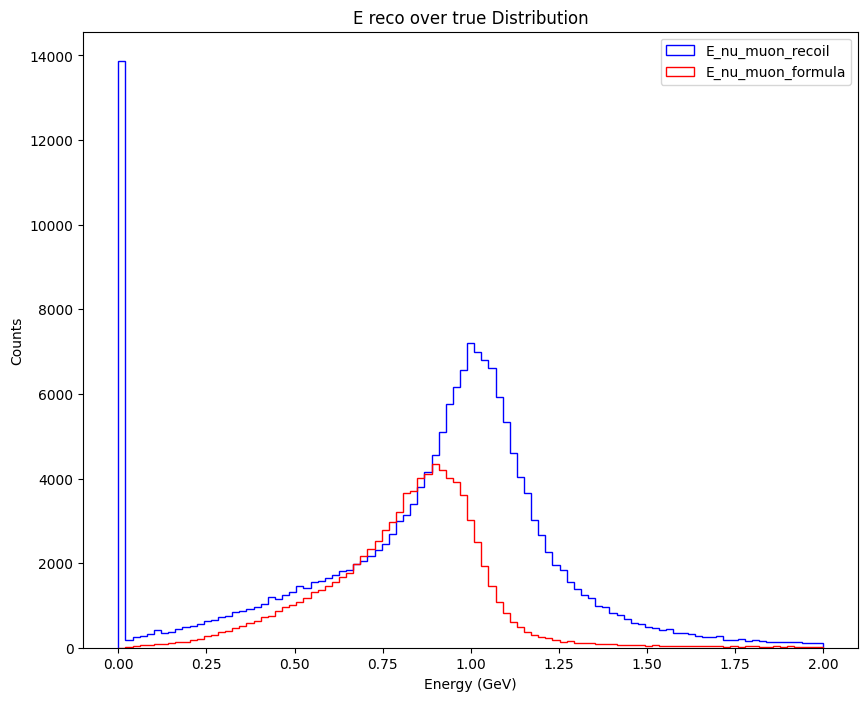

In [ ]:
E_nu_muon_formula = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_nu_true = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
bins = np.linspace(0, 2, 100)
ax.hist(E_nu_muon_recoil / E_nu_true, bins=bins, histtype='step', color='blue', label='E_nu_muon_recoil')
ax.hist(E_nu_muon_formula / E_nu_true, bins=bins, histtype='step', color='red', label='E_nu_muon_formula')
ax.set_xlabel("Energy (GeV)")
ax.set_ylabel("Counts")
ax.legend()
ax.set_title("E reco over true Distribution")
fig.show()

In [ ]:
E_sum_blob_per_event = np.zeros(blob.n.shape[0])
E_sum_prong_per_event = np.zeros(prong.n.shape[0])
for i in range(blob.n.shape[0]):
    E_sum_blob_per_event[i] = np.sum(blob.data[blob.bounds[i]:blob.bounds[i+1], 5])
    E_sum_prong_per_event[i] = np.sum(prong.data[prong.bounds[i]:prong.bounds[i+1], ])
E_sum_blob_per_event[:10], E_sum_prong_per_event[:10]


(array([311.93551636,   0.        ,   8.81560135,   0.        ,
         17.75290489, 222.90682983, 368.35882568, 153.00085449,
        961.40026855,   0.        ]),
 array([38244.6015625 , 21866.12304688, 37524.48046875, 28091.79296875,
        20353.30078125, 76065.7578125 , 26516.90234375, 17832.1796875 ,
        40185.24609375, 17821.10351562]))

NameError: name 'E_mu' is not defined

array([16.95806921,  5.05747995,  5.31970144, ...,  3.96306456,
        8.00965275,  7.04304398])